In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

root_dir = os.path.abspath("..")
if root_dir not in sys.path:
    sys.path.append(root_dir)

from current_setpoints.models.machines import PMSMParams, PMSMDrive, ieee_machine2_params
from current_setpoints.models.forward_model import ForwardModel, Fault
from current_setpoints.optimization.optimizer import StaticOptimizer

# Raw, as-identified L_stat -- copied from ieee_machine2_params' own source
# comment (the factory symmetrizes it before returning, so it isn't exposed
# as a public value; kept here verbatim for provenance).
L_STAT_RAW = 1e-3 * np.array(
    [
        [0.0920, -0.0286, -0.0141, 0.0010],
        [-0.0133, 0.1090, -0.0008, -0.0092],
        [-0.0088, 0.0037, 0.0725, -0.0466],
        [-0.0041, -0.0053, 0.0475, 0.0722],
    ]
)

params_sym = ieee_machine2_params()  # symmetrized internally
params_asym = PMSMParams(
    n_phases=params_sym.n_phases,
    n_ppairs=params_sym.n_ppairs,
    R_stat=params_sym.R_stat,
    L_stat=L_STAT_RAW,
    flux_pm=params_sym.flux_pm,
    curr_max=params_sym.curr_max,
    volt_max=params_sym.volt_max,
)

drive_sym = PMSMDrive(params_sym)
drive_asym = PMSMDrive(params_asym)

solver_opts = {"disp": False, "ftol": 1e-8, "maxiter": 300}
fwd_sym = ForwardModel(drive_sym, fault=Fault(()), n_theta=700)
fwd_asym = ForwardModel(drive_asym, fault=Fault(()), n_theta=700)
opt_sym = StaticOptimizer(fwd_sym, solver_opts)
opt_asym = StaticOptimizer(fwd_asym, solver_opts)

CONST_MECH_SPEED = 30.0 / (np.pi * drive_sym.n_ppairs)  # rpm = omega_elec * CONST_MECH_SPEED

print(f"max |L_sym - L_sym^T|  = {np.max(np.abs(params_sym.L_stat - params_sym.L_stat.T)):.2e}")
print(f"max |L_asym - L_asym^T| = {np.max(np.abs(L_STAT_RAW - L_STAT_RAW.T)):.2e}")
print(f"max asymmetric entry, as a fraction of L_asym's largest entry: "
      f"{np.max(np.abs(L_STAT_RAW - L_STAT_RAW.T)) / np.max(np.abs(L_STAT_RAW)):.1%}")

max |L_sym - L_sym^T|  = 0.00e+00
max |L_asym - L_asym^T| = 9.41e-05
max asymmetric entry, as a fraction of L_asym's largest entry: 86.3%


In [2]:
torques_zero_speed = np.linspace(0.5, 6.0, 12)
max_diff_zero_speed = 0.0
for T in torques_zero_speed:
    s_sym = opt_sym.minimize_current(T, 0.0)
    s_asym = opt_asym.minimize_current(T, 0.0)
    if not (s_sym.success and s_asym.success):
        print(f"T={T:.2f}: infeasible (sym={s_sym.success}, asym={s_asym.success})")
        continue
    diff = np.linalg.norm(s_asym.curr_dq - s_sym.curr_dq)
    max_diff_zero_speed = max(max_diff_zero_speed, diff)

print(f"max ||i_asym - i_sym|| across the whole omega=0 torque sweep: {max_diff_zero_speed:.2e} A")

max ||i_asym - i_sym|| across the whole omega=0 torque sweep: 4.70e-05 A


In [3]:
# Verify the identity directly: the antisymmetric part of L_stat contributes
# exactly zero to the torque quadratic form x^T A x, for arbitrary x.
J = np.array([[0, -1, 0, 0], [1, 0, 0, 0], [0, 0, 0, -3], [0, 0, 3, 0]])
L_anti = L_STAT_RAW - params_sym.L_stat  # the part symmetrization removed


def A_of(L):
    return J @ L + L @ J.T


rng = np.random.default_rng(0)
max_quad_form = 0.0
for _ in range(200):
    x = rng.normal(size=4)
    max_quad_form = max(max_quad_form, abs(x @ A_of(L_anti) @ x))

print(f"max |x^T A(L_anti) x| over 200 random x: {max_quad_form:.2e}  (should be ~0)")

max |x^T A(L_anti) x| over 200 random x: 1.36e-20  (should be ~0)


In [4]:
# Non-uniform grid: coarse below the field-weakening transition (both models
# are identical there, per the zero-speed proof above, so dense sampling
# adds nothing), fine through the transition and up to the feasibility
# boundary -- this single sweep also gives us the feasibility boundary
# directly, no separate rerun needed.
rpm_grid = np.concatenate([np.arange(0, 1100, 200), np.arange(1100, 1751, 25)])

tmax_sym_arr = np.full(len(rpm_grid), np.nan)
tmax_asym_arr = np.full(len(rpm_grid), np.nan)
i_sym_arr = np.full((len(rpm_grid), 4), np.nan)
i_asym_arr = np.full((len(rpm_grid), 4), np.nan)

for k, rpm in enumerate(rpm_grid):
    omega = rpm / CONST_MECH_SPEED
    tmax_sym = opt_sym.maximize_torque(omega)
    tmax_asym = opt_asym.maximize_torque(omega)
    if tmax_sym.success:
        tmax_sym_arr[k] = tmax_sym.torque
    if tmax_asym.success:
        tmax_asym_arr[k] = tmax_asym.torque
    if not (tmax_sym.success and tmax_asym.success):
        continue

    T = 0.97 * min(tmax_sym.torque, tmax_asym.torque)
    s_sym = opt_sym.minimize_current(T, omega)
    s_asym = opt_asym.minimize_current(T, omega)
    if s_sym.success:
        i_sym_arr[k] = s_sym.curr_dq
    if s_asym.success:
        i_asym_arr[k] = s_asym.curr_dq

diff_norm = np.linalg.norm(i_asym_arr - i_sym_arr, axis=1)

first_fail_sym = rpm_grid[np.isnan(tmax_sym_arr)][0] if np.any(np.isnan(tmax_sym_arr)) else None
first_fail_asym = rpm_grid[np.isnan(tmax_asym_arr)][0] if np.any(np.isnan(tmax_asym_arr)) else None
max_diff_idx = np.nanargmax(diff_norm)

print(f"max ||i_asym - i_sym|| = {diff_norm[max_diff_idx]:.3f} A at rpm={rpm_grid[max_diff_idx]}")
print(f"maximize_torque first fails: symmetrized L_stat at rpm={first_fail_sym}, "
      f"raw (asymmetric) L_stat at rpm={first_fail_asym}")

max ||i_asym - i_sym|| = 2.626 A at rpm=1300
maximize_torque first fails: symmetrized L_stat at rpm=1725, raw (asymmetric) L_stat at rpm=1725


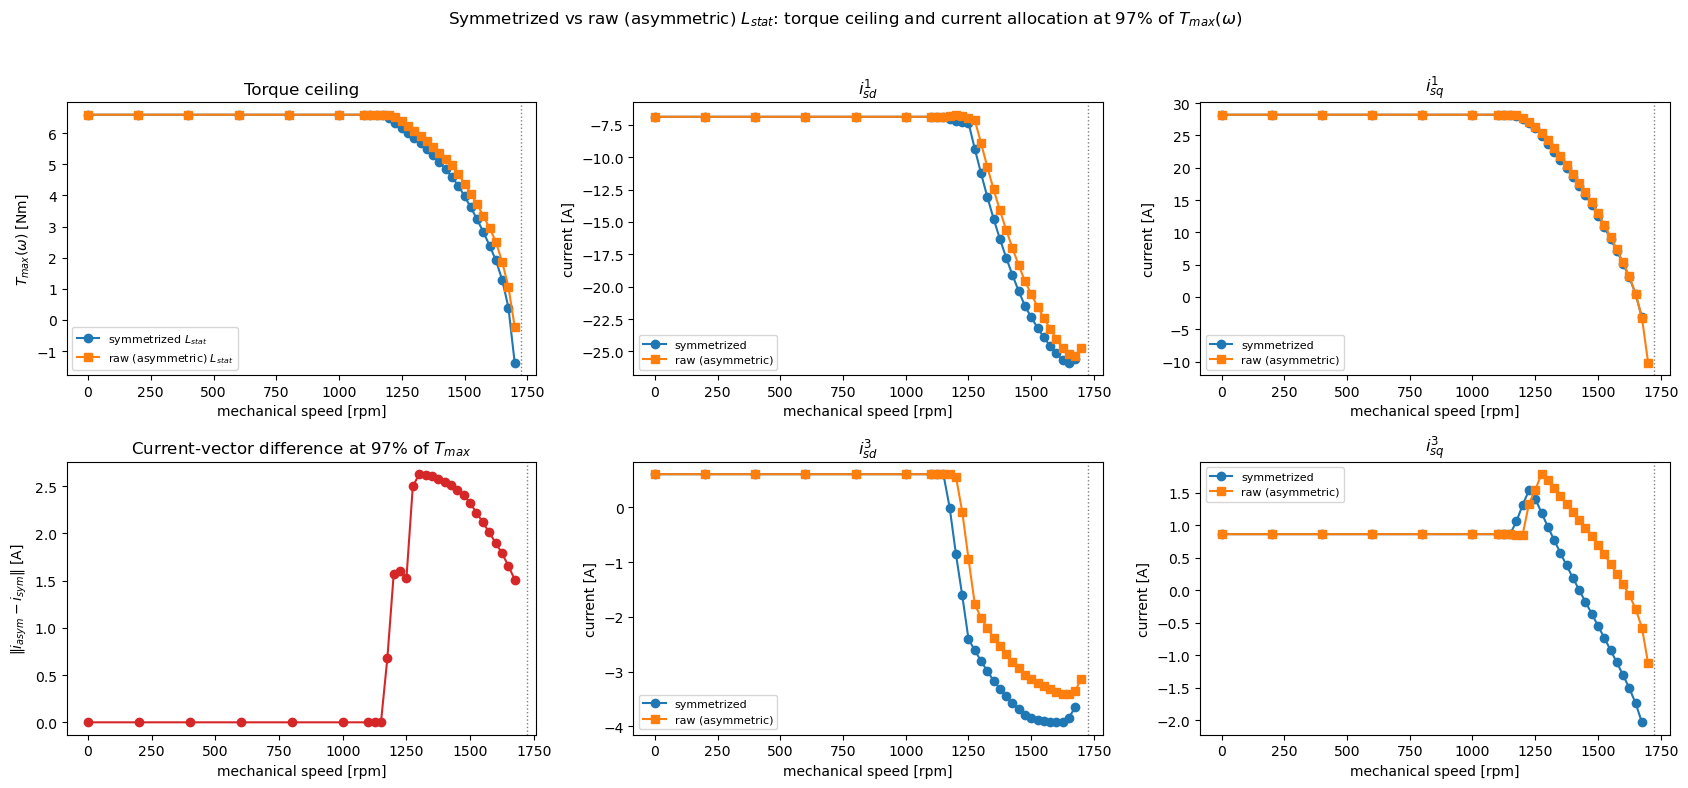

In [5]:
dq_labels = [r"$i_{sd}^1$", r"$i_{sq}^1$", r"$i_{sd}^3$", r"$i_{sq}^3$"]
fig, ax = plt.subplots(2, 3, figsize=(17, 8))
boundary_rpm = min(x for x in (first_fail_sym, first_fail_asym) if x is not None)

a = ax[0, 0]
a.plot(rpm_grid, tmax_sym_arr, "o-", label="symmetrized $L_{stat}$")
a.plot(rpm_grid, tmax_asym_arr, "s-", label="raw (asymmetric) $L_{stat}$")
a.set_title("Torque ceiling")
a.set_xlabel("mechanical speed [rpm]"); a.set_ylabel(r"$T_{max}(\omega)$ [Nm]")
a.legend(fontsize=8)

a = ax[1, 0]
a.plot(rpm_grid, diff_norm, "o-", color="tab:red")
a.set_title("Current-vector difference at 97% of $T_{max}$")
a.set_xlabel("mechanical speed [rpm]"); a.set_ylabel(r"$\|i_{asym} - i_{sym}\|$ [A]")

for idx, (row, col) in enumerate([(0, 1), (0, 2), (1, 1), (1, 2)]):
    a = ax[row, col]
    a.plot(rpm_grid, i_sym_arr[:, idx], "o-", label="symmetrized")
    a.plot(rpm_grid, i_asym_arr[:, idx], "s-", label="raw (asymmetric)")
    a.set_title(dq_labels[idx])
    a.set_xlabel("mechanical speed [rpm]"); a.set_ylabel("current [A]")
    a.legend(fontsize=8)

for a in ax.flat:
    a.axvline(boundary_rpm, color="gray", ls=":", lw=1)

fig.suptitle("Symmetrized vs raw (asymmetric) $L_{stat}$: torque ceiling and current allocation at 97% of $T_{max}(\\omega)$", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()